# 03 — Spectral Analysis and Visualization
Exploratory analysis of the final dataset: spectral shapes,
second derivative signatures, and species separation.


In [8]:
import sys
from phytospec import config as cfg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from phytospec.algorithms import compute_CHL, compute_MALH, compute_D2, interp_at
from phytospec.algorithms import lubac_phaeo_index
from phytospec import load_datacube



In [9]:
STATION = "RT1"
YEAR    = 2025

dataset_path = cfg.DATA_PROCESSED / f"REFERENCE_DATASET_4_WP2_{STATION}_{YEAR}.csv"
df = pd.read_csv(dataset_path, parse_dates=['date'])

# reconstruct wavelength grid from column names
rhow_cols  = [c for c in df.columns if c.startswith('rhow_')]
d2row_cols = [c for c in df.columns if c.startswith('D2rhow_')]
wl = np.array([float(c.split('_')[1]) for c in rhow_cols])

print(f"Loaded: {len(df)} days, {len(rhow_cols)} wavelength bands")
print(f"P. globosa days : {(df.P_LUB == 1).sum()}")
print(f"Diatom days     : {(df.P_LUB == 0).sum()}")


Loaded: 112 days, 237 wavelength bands
P. globosa days : 11
Diatom days     : 101


## Mean spectra: P. globosa vs Diatoms

P. globosa rows : 11
Diatom rows     : 101


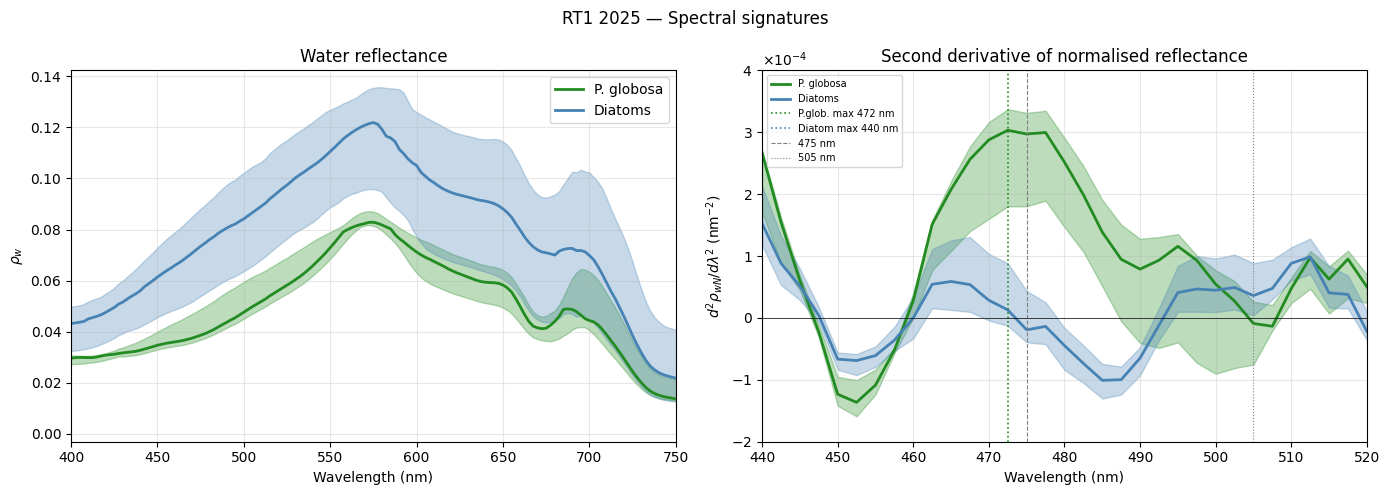

In [11]:
# ── Build everything from dataset — no dependency on external wl or df ─────────
_rhow_cols  = [c for c in df.columns if c.startswith('rhow_')
               and not c.startswith('D2')]
_d2row_cols = [c for c in df.columns if c.startswith('D2rhow_')]
_wl         = np.array([float(c.split('_')[1]) for c in _rhow_cols])

# Sanity check — catch mismatches before they cause silent blank plots
assert len(_d2row_cols) == len(_wl), \
    f"d2row_cols ({len(_d2row_cols)}) != wl ({len(_wl)}) — column mismatch"
assert df['P_LUB'].sum() > 0, \
    "No P. globosa rows (P_LUB=1) in dataset — re-run make_dataset first"

# ── Split by species ───────────────────────────────────────────────────────────
_phaeo  = df[df['P_LUB'] == 1]
_diatom = df[df['P_LUB'] == 0]
print(f"P. globosa rows : {len(_phaeo)}")
print(f"Diatom rows     : {len(_diatom)}")

# ── Slice wavelength mask for D2 panel ─────────────────────────────────────────
_wl_mask = (_wl >= 440) & (_wl <= 520)
_wl_d2   = _wl[_wl_mask]

_phaeo_rhow  = _phaeo[_rhow_cols].values.astype(float)
_diatom_rhow = _diatom[_rhow_cols].values.astype(float)

_phaeo_d2    = _phaeo[_d2row_cols].values[:,  _wl_mask].astype(float)
_diatom_d2   = _diatom[_d2row_cols].values[:, _wl_mask].astype(float)

# Median and IQR
_med_p_rhow = np.nanmedian(_phaeo_rhow,  axis=0)
_med_d_rhow = np.nanmedian(_diatom_rhow, axis=0)
_med_p_d2   = np.nanmedian(_phaeo_d2,    axis=0)
_med_d_d2   = np.nanmedian(_diatom_d2,   axis=0)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Left: raw reflectance —
ax = axes[0]
ax.fill_between(_wl,
                np.nanpercentile(_phaeo_rhow,  25, axis=0),
                np.nanpercentile(_phaeo_rhow,  75, axis=0),
                alpha=0.3, color='forestgreen')
ax.fill_between(_wl,
                np.nanpercentile(_diatom_rhow, 25, axis=0),
                np.nanpercentile(_diatom_rhow, 75, axis=0),
                alpha=0.3, color='steelblue')
ax.plot(_wl, _med_p_rhow, color='forestgreen', lw=2, label='P. globosa')
ax.plot(_wl, _med_d_rhow, color='steelblue',   lw=2, label='Diatoms')
ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
       title='Water reflectance', xlim=(400, 750))
ax.legend(); ax.grid(alpha=0.3)

# — Right: second derivative —
ax = axes[1]
ax.fill_between(_wl_d2,
                np.nanpercentile(_phaeo_d2,  25, axis=0),
                np.nanpercentile(_phaeo_d2,  75, axis=0),
                alpha=0.3, color='forestgreen')
ax.fill_between(_wl_d2,
                np.nanpercentile(_diatom_d2, 25, axis=0),
                np.nanpercentile(_diatom_d2, 75, axis=0),
                alpha=0.3, color='steelblue')
ax.plot(_wl_d2, _med_p_d2, color='forestgreen', lw=2, label='P. globosa')
ax.plot(_wl_d2, _med_d_d2, color='steelblue',   lw=2, label='Diatoms')

# Annotate peak positions
_peak_p_wl = _wl_d2[np.nanargmax(_med_p_d2)]
_peak_d_wl = _wl_d2[np.nanargmax(_med_d_d2)]
ax.axvline(_peak_p_wl, color='forestgreen', linestyle=':', lw=1.2,
           label=f'P.glob. max {_peak_p_wl:.0f} nm')
ax.axvline(_peak_d_wl, color='steelblue',   linestyle=':', lw=1.2,
           label=f'Diatom max {_peak_d_wl:.0f} nm')
ax.axvline(475, color='grey', linestyle='--', lw=0.8, label='475 nm')
ax.axvline(505, color='grey', linestyle=':',  lw=0.8, label='505 nm')
ax.axhline(0,   color='k',    lw=0.5)

ax.set_xlim(440, 520)
ax.set_ylim(-2e-4, 4e-4)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$d^2\rho_{wN}/d\lambda^2$ (nm$^{-2}$)')
ax.set_title('Second derivative of normalised reflectance')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle(f'{STATION} {YEAR} — Spectral signatures', fontsize=12)
plt.tight_layout()
plt.show()

## MALH scatter by P_LUB class

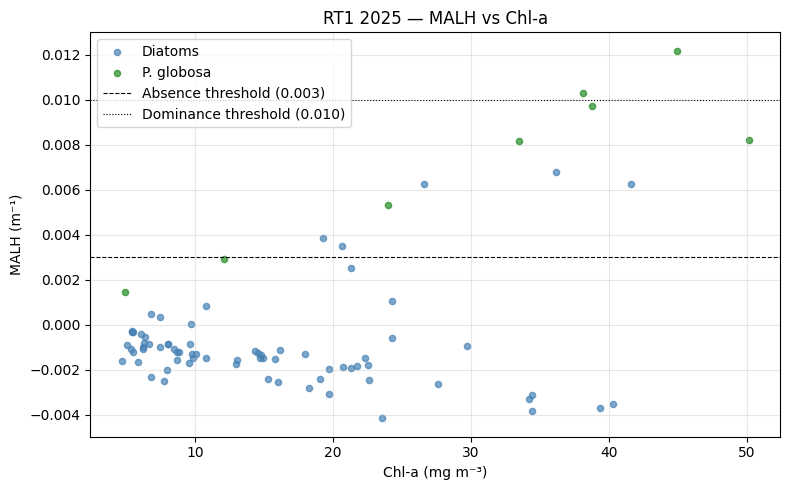

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, color, name in [(0, 'steelblue', 'Diatoms'),
                            (1, 'forestgreen', 'P. globosa')]:
    sub = df[df.P_LUB == label]
    ax.scatter(sub['CHL'], sub['MALH'], c=color, s=20,
               alpha=0.7, label=name)

ax.axhline(0.003, color='k', linestyle='--', lw=0.8, label='Absence threshold (0.003)')
ax.axhline(0.010, color='k', linestyle=':',  lw=0.8, label='Dominance threshold (0.010)')
ax.set(xlabel='Chl-a (mg m⁻³)', ylabel='MALH (m⁻¹)',
       title=f'{STATION} {YEAR} — MALH vs Chl-a')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Full time series: CHL and MALH for ALL spectra

[io] Datacube loaded ← C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\datacube_RT1_2025.npz  (2255 spectra)
Total spectra in datacube: 2255
CHL computed   : 1529
P. globosa (1) : 299
Diatoms    (0) : 1956


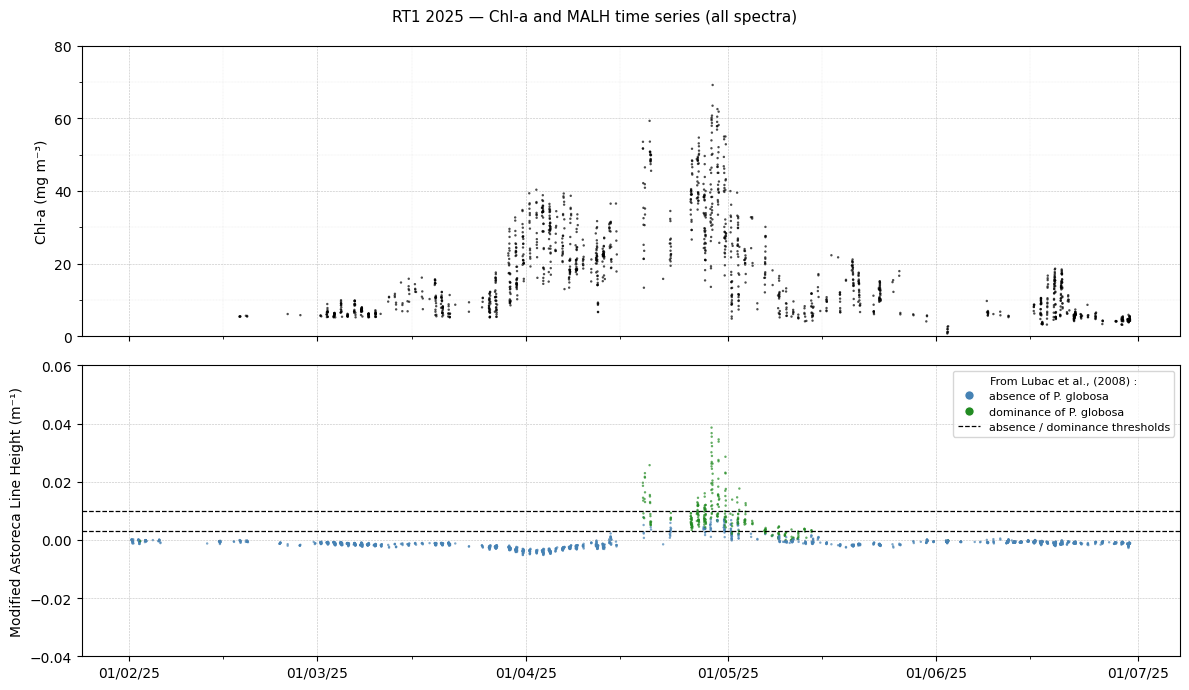

In [13]:
# ── Full time series: CHL and MALH for ALL spectra using Python datacube ────────
# ── Load datacube (all raw spectra) ───────────────────────────────────────────
cube_path = cfg.DATA_PROCESSED / f"datacube_{STATION}_{YEAR}.npz"
datacube  = load_datacube(cube_path)

_RHOW   = datacube["RHOW"]
_wl     = datacube["wl"]
_dates  = pd.to_datetime(datacube["dateP"], utc=True)
_SZA    = datacube["SZA"]
N       = len(_dates)
print(f"Total spectra in datacube: {N}")

# ── Compute CHL, MALH, P_LUB for every spectrum ───────────────────────────────
_chl  = np.full(N, np.nan)
_malh = np.full(N, np.nan)
_plub = np.zeros(N, dtype=int)

for i in range(N):
    rhow_i = _RHOW[i, :]
    if np.sum(~np.isnan(rhow_i)) < 200:   # same QC threshold as make_dataset
        continue
    _chl[i]  = compute_CHL(rhow_i, _wl)
    _malh[i] = compute_MALH(rhow_i, _wl)
    d2_i     = compute_D2(rhow_i, _wl)
    _plub[i] = lubac_phaeo_index(_wl, d2_i)

print(f"CHL computed   : {np.sum(~np.isnan(_chl))}")
print(f"P. globosa (1) : {int(np.sum(_plub == 1))}")
print(f"Diatoms    (0) : {int(np.sum(_plub == 0))}")

# ── Colours ────────────────────────────────────────────────────────────────────
# Top    (CHL) : black = valid,  grey = NaN
# Bottom (MALH): blue  = absent, green = dominant
_chl_colors  = np.where(~np.isnan(_chl), "black", "lightgrey")
_malh_colors = np.where(_plub == 1, "forestgreen", "steelblue")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# — Top: CHL —
ax1.scatter(_dates, _chl,  c=_chl_colors, s=3, alpha=0.7, linewidths=0)
ax1.set_ylabel("Chl-a (mg m⁻³)")
ax1.set_ylim(0, 80)
ax1.yaxis.set_major_locator(plt.MultipleLocator(20))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(10))
ax1.grid(which='major', color='grey', linestyle='--', linewidth=0.4, alpha=0.5)
ax1.grid(which='minor', color='grey', linestyle='--', linewidth=0.2, alpha=0.3)

# — Bottom: MALH —
ax2.scatter(_dates, _malh, c=_malh_colors, s=3, alpha=0.7, linewidths=0)
ax2.axhline(0.003, color='k', linestyle='--', lw=0.9)
ax2.axhline(0.010, color='k', linestyle='--', lw=0.9)
ax2.set_ylabel("Modified Astoreca Line Height (m⁻¹)")
ax2.set_ylim(-0.04, 0.06)
ax2.grid(which='major', color='grey', linestyle='--', linewidth=0.4, alpha=0.5)
ax2.legend(
    handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, label='absence of P. globosa'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='forestgreen',
               markersize=7, label='dominance of P. globosa'),
        Line2D([0],[0], color='k', linestyle='--', lw=0.9,
               label='absence / dominance thresholds'),
    ],
    title="From Lubac et al., (2008) :",
    fontsize=8, title_fontsize=8, loc='upper right'
)

# — X axis —
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_minor_locator(mdates.DayLocator(bymonthday=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
fig.autofmt_xdate(rotation=0, ha='center')

fig.suptitle(f"{STATION} {YEAR} — Chl-a and MALH time series (all spectra)",
             fontsize=11)
plt.tight_layout()
plt.savefig(cfg.DATA_PROCESSED / f"timeseries_all_spectra_{STATION}_{YEAR}.png",
            dpi=200, bbox_inches='tight')
plt.show()